In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# Step1:準備資料

In [3]:
iris=datasets.load_iris()

In [4]:
X=iris.data
X=X[:,2:4]

# Step2:建立模型
## n_clusters: k值
## init: 'random' / 'k-means++'(根據設定的K值決定要幾個初始點) / 自行給定
## max_iter: 最多迭代次數(模型若無法有效收斂最好給一個最大迭代次數)
## tol: 中心點誤差忍受 (會持續更新群心到固定為止，有可能無法收斂，因此方寬條件，給予誤差忍受。最好不要設0)
## random_state: 隨機種子(每次都隨機選取特徵，設定一個數字才能確保每一次選擇的特徵都是一樣的，不然分類結果可能每一次都不一樣)

In [5]:
KM = KMeans(n_clusters=3,init='random',random_state=5)
KM.fit(X)

C:\Users\jocel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\jocel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(init='random', n_clusters=3, random_state=5)

# Step3: 進行分群

In [6]:
#剛才設定K值為3，所以結果會有0、1、2
KM.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# Step4: 圖像化結果

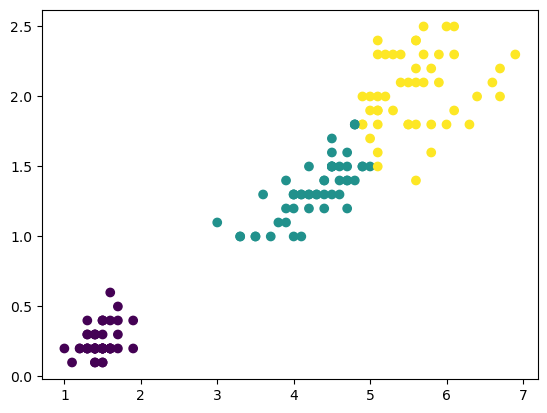

In [7]:
plt.scatter(X[:,0],X[:,1],c = KM.predict(X))

# 額外補充: 與真實情況對照

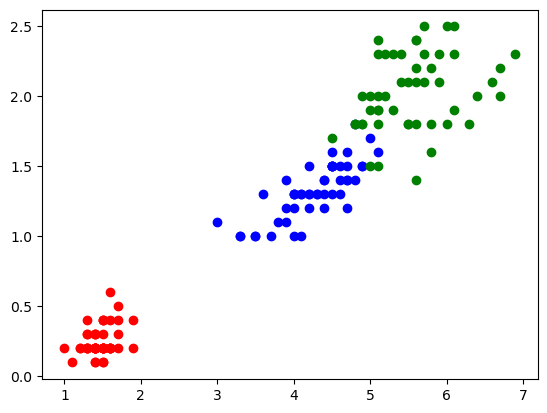

In [8]:
#畫出原始答案的scatter圖
iris=datasets.load_iris()
features=iris.data
target=iris.target
target_names=iris.target_names
labels=target_names[target]

setosa_petal_length=features[labels=='setosa',2]
setosa_petal_width=features[labels=='setosa',3]
setosa=np.c_[setosa_petal_length,setosa_petal_width]

versicolor_petal_length=features[labels=='versicolor',2]
versicolor_petal_width=features[labels=='versicolor',3]
versicolor=np.c_[versicolor_petal_length,versicolor_petal_width]

virginica_petal_length=features[labels=='virginica',2]
virginica_petal_width=features[labels=='virginica',3]
virginica=np.c_[virginica_petal_length,virginica_petal_width]

plt.scatter(setosa[:,0],setosa[:,1],color='red')
plt.scatter(versicolor[:,0],versicolor[:,1],color='blue')
plt.scatter(virginica[:,0],virginica[:,1],color='green')

# K-Medoids
## 中心點為實際樣本點，且新中心點的決定方式為選取使群內距離和最小的點(kmeans是群內平均值)
> pip install scikit-learn-extra (sklearn_extra套件沒有包含在Anaconda裡面，所以要另外install)

In [10]:
from sklearn_extra.cluster import KMedoids

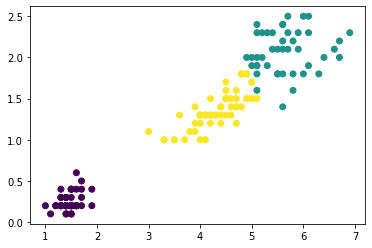

In [11]:
KMed = KMedoids(n_clusters=3,init='random',random_state=5)
KMed.fit(X)
KMed.predict(X)
plt.scatter(X[:,0],X[:,1],c = KMed.predict(X))